In [2]:
import os
from dotenv import load_dotenv
import json
import csv
import re
import math
from datetime import datetime, timezone
from docx import Document
from random import choice
from string import Template
from typing import Union
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import tiktoken
from openai import OpenAI
from pydantic import BaseModel, Field, ValidationError
from sklearn.metrics import accuracy_score, mean_absolute_error, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import spearmanr, pearsonr
import pingouin as pg

# Data Imports

In [ ]:
#Create a Path object for current working directory
cwd = Path.cwd()
print(cwd)

In [4]:
# Define required directories within cwd
required_dirs = ["data", "jsonl_files", "model_outputs", "evaluation"]

# Create them if they do not exist
for folder in required_dirs:
    (cwd / folder).mkdir(exist_ok=True)

In [5]:
''' 
main_data_df initial contains all 19 questions. Image questions are subsequently dropped from this df
It does NOT contain the questions which were removed manually for few-shot examples.
Few shot examples are loaded separately in few_shot_questions_df 
'''
main_data_path = cwd / "data" / "yr1_may2022_main_data.csv" 
main_data_df = pd.read_csv(main_data_path)
#main_data_df

In [6]:
few_shot_questions_path = cwd / "data" / "few_shot_questions.csv"
few_shot_df = pd.read_csv(few_shot_questions_path)
#few_shot_df

In [7]:
# load df containing details of each question
question_parameters_path = cwd / "data" / "yr1_may2022_question_parameters.csv"
question_parameters_df =pd.read_csv(question_parameters_path)


# Model calls to unaltered GPT 5.6-terra model 

Retrieve API key from .env and instantiate client

In [7]:
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")
#print(openai_api_key[:5], "******", openai_api_key[-5:])
client = OpenAI()

Define function to make model calls

In [8]:
def call_llm(
    jsonl_file,
    main_data_df,
    client,
    model="gpt-5.6-terra",
    interim_out_dir="interim_outputs",
    final_csv_suffix="",
    max_rows=None,
    reasoning_effort="medium",
    max_output_tokens=25_000,
):
    """
    Calls the Responses API using Pydantic Structured Outputs.

    max_rows:
        Optional limit on the number of non-empty JSONL records processed.
    """

    dataset = jsonl_file.stem
    run_name = f"{dataset}{final_csv_suffix}"
    rows = []
    processed_rows = 0

    class OutputSchema(BaseModel):
        student_id: Union[str, int]
        question_id: Union[str, int]
        marker_score: float = Field(ge=0)
        max_score: float = Field(gt=0)
        marker_feedback: str = Field(min_length=1)

    REQUIRED = {
        "student_id",
        "question_id",
        "marker_score",
        "max_score",
        "marker_feedback",
    }

    error_path = Path(interim_out_dir) / f"{run_name}_parse_errors.jsonl"
    error_path.parent.mkdir(parents=True, exist_ok=True)

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):

            line = line.strip()
            if not line:
                continue

            if max_rows is not None and processed_rows >= max_rows:
                break

            processed_rows += 1

            obj = json.loads(line)
            messages = obj["messages"]

            response = None
            parsed = {}
            raw = ""
            status = None
            incomplete_reason = None
            api_error = None

            try:
                response = client.responses.parse(
                    model=model,
                    input=messages,
                    reasoning={"effort": reasoning_effort},
                    max_output_tokens=max_output_tokens,
                    text_format=OutputSchema,
                )

                raw = response.output_text or ""
                status = getattr(response, "status", None)

                incomplete_details = getattr(
                    response,
                    "incomplete_details",
                    None,
                )

                incomplete_reason = (
                    getattr(incomplete_details, "reason", None)
                    if incomplete_details
                    else None
                )

                if status == "incomplete":
                    print(
                        f"Row {i}: incomplete response; "
                        f"reason={incomplete_reason}"
                    )

                else:
                    parsed_obj = getattr(
                        response,
                        "output_parsed",
                        None,
                    )

                    if parsed_obj is not None:
                        parsed = parsed_obj.model_dump()
                        print(f"Route A: row {i} parsed successfully")

                    elif raw:
                        try:
                            cleaned = clean_json_text(raw)

                            parsed_obj = (
                                OutputSchema.model_validate_json(
                                    cleaned
                                )
                            )

                            parsed = parsed_obj.model_dump()
                            print(
                                f"Route B: row {i} recovered "
                                "from raw output"
                            )

                        except (
                            ValidationError,
                            json.JSONDecodeError,
                        ) as parse_error:
                            print(
                                f"Row {i}: raw-output parsing "
                                f"failed: {parse_error}"
                            )

                    else:
                        print(
                            f"Row {i}: completed response contained "
                            "neither parsed nor raw output"
                        )

            except Exception as exc:
                api_error = repr(exc)
                print(f"Row {i}: API call failed: {api_error}")

            # Usage information
            usage = (
                getattr(response, "usage", None)
                if response is not None
                else None
            )

            input_tokens = (
                getattr(usage, "input_tokens", None)
                if usage
                else None
            )

            output_tokens = (
                getattr(usage, "output_tokens", None)
                if usage
                else None
            )

            total_tokens = (
                getattr(usage, "total_tokens", None)
                if usage
                else None
            )

            # Cached input tokens
            input_details = (
                getattr(usage, "input_tokens_details", None)
                if usage
                else None
            )

            cached_input_tokens = (
                getattr(input_details, "cached_tokens", 0)
                if input_details
                else 0
            )

            output_details = (
                getattr(usage, "output_tokens_details", None)
                if usage
                else None
            )

            reasoning_tokens = (
                getattr(output_details, "reasoning_tokens", None)
                if output_details
                else None
            )

            parse_ok = (
                isinstance(parsed, dict)
                and REQUIRED.issubset(parsed)
            )

            row = {
                "Dataset": dataset,
                "Student_ID": parsed.get("student_id"),
                "Question_ID": parsed.get("question_id"),
                "Model_score": parsed.get("marker_score"),
                "Max_score": parsed.get("max_score"),
                "Model_feedback": parsed.get("marker_feedback"),
                "Token_count": total_tokens,
                "Input_tokens": input_tokens,
                "Cached_input_tokens": cached_input_tokens,
                "Output_tokens": output_tokens,
                "Reasoning_tokens": reasoning_tokens,
                "Response_status": status,
                "Incomplete_reason": incomplete_reason,
                "API_error": api_error,
                "Log_Probs": None,
                "Raw_output": raw,
                "Model": model,
                "Reasoning_effort": reasoning_effort,
                "Max_output_tokens": max_output_tokens,
                "Timestamp_UTC": datetime.now(
                    timezone.utc
                ).isoformat(),
                "Row_Index": i,
                "Parse_Ok": parse_ok,
            }

            save_row_to_csv(
                run_name,
                row,
                out_dir=interim_out_dir,
            )

            if not parse_ok:
                print(
                    f"WARNING: row {i} failed; "
                    f"status={status}; "
                    f"reason={incomplete_reason}; "
                    f"output_tokens={output_tokens}; "
                    f"reasoning_tokens={reasoning_tokens}"
                )

                with error_path.open(
                    "a",
                    encoding="utf-8",
                ) as ef:
                    ef.write(
                        json.dumps(
                            {
                                "row_index": i,
                                "status": status,
                                "incomplete_reason": incomplete_reason,
                                "api_error": api_error,
                                "output_tokens": output_tokens,
                                "reasoning_tokens": reasoning_tokens,
                                "raw_output": raw,
                            },
                            ensure_ascii=False,
                        )
                        + "\n"
                    )

            rows.append(row)

    model_responses_interim = pd.DataFrame(rows)

    try:
        output_df = align_tidy_outputs(
            model_responses_interim,
            main_data_df,
        )

        output_filename = f"{run_name}.csv"
        output_directory = cwd / "model_outputs"
        output_directory.mkdir(parents=True, exist_ok=True)

        output_file_path = output_directory / output_filename
        output_df.to_csv(output_file_path, index=False)

        return output_df

    except Exception as exc:
        print(
            "WARNING: alignment failed; returning interim "
            f"outputs. Error: {exc}"
        )
        return model_responses_interim

Helper functions to assist model call function

In [9]:
def save_row_to_csv(
    run_name,
    row,
    out_dir="interim_outputs",
):
    """
    Append one response to a run-specific interim CSV.
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    path = out_dir / f"{run_name}_interim.csv"
    write_header = (
        not path.exists()
        or path.stat().st_size == 0
    )

    with path.open(
        "a",
        newline="",
        encoding="utf-8",
    ) as f:
        writer = csv.DictWriter(
            f,
            fieldnames=row.keys(),
        )

        if write_header:
            writer.writeheader()

        writer.writerow(row)

In [12]:
def align_tidy_outputs(model_responses, main_data_df):
    """
    Merge model outputs with human data without failing when human
    identifier pairs are duplicated.
    """

    model_responses = model_responses.copy()
    human_data = main_data_df.copy()

    def normalise_id(series):
        values = series.astype("string").str.strip()

        numeric = pd.to_numeric(values, errors="coerce")
        integer_like = numeric.notna() & numeric.mod(1).eq(0)

        values.loc[integer_like] = (
            numeric.loc[integer_like]
            .astype("Int64")
            .astype("string")
        )

        return values

    # Normalise identifiers
    model_responses["Student_ID"] = normalise_id(
        model_responses["Student_ID"]
    )
    model_responses["Question_ID"] = normalise_id(
        model_responses["Question_ID"]
    )

    human_data["student_id"] = normalise_id(
        human_data["student_id"]
    )
    human_data["question_id"] = normalise_id(
        human_data["question_id"]
    )

    human_subset = human_data[
        [
            "student_id",
            "question_id",
            "marker_score",
            "marker_feedback",
        ]
    ].copy()

    # Preserve the original human dataframe row for investigation
    human_subset["Human_Source_Row"] = human_subset.index

    # Reduce the human data to one record per identifier pair
    resolved_records = []

    for (student_id, question_id), group in human_subset.groupby(
        ["student_id", "question_id"],
        dropna=False,
        sort=False,
    ):
        unique_outcomes = group[
            ["marker_score", "marker_feedback"]
        ].drop_duplicates()

        ambiguous = len(unique_outcomes) > 1
        first_outcome = unique_outcomes.iloc[0]

        candidate_records = group[
            [
                "Human_Source_Row",
                "marker_score",
                "marker_feedback",
            ]
        ].copy()

        candidate_records = candidate_records.where(
            pd.notna(candidate_records),
            None,
        )

        resolved_records.append(
            {
                "student_id": student_id,
                "question_id": question_id,

                # Retain values when the duplicate rows agree
                "Human_Marker_Score": (
                    None
                    if ambiguous
                    else first_outcome["marker_score"]
                ),
                "Human_Marker_Feedback": (
                    None
                    if ambiguous
                    else first_outcome["marker_feedback"]
                ),

                "Human_Match_Count": len(group),
                "Human_Unique_Outcome_Count": len(
                    unique_outcomes
                ),

                # Allows conflicting duplicates to be reviewed manually
                "Human_Match_Candidates": json.dumps(
                    candidate_records.to_dict("records"),
                    ensure_ascii=False,
                    default=str,
                ),
            }
        )

    resolved_human = pd.DataFrame(resolved_records)

    # Count duplicate human identifiers
    duplicate_groups = resolved_human[
        resolved_human["Human_Match_Count"] > 1
    ]

    model_keys = model_responses[
        ["Student_ID", "Question_ID"]
    ].drop_duplicates()

    relevant_duplicate_groups = model_keys.merge(
        duplicate_groups[
            ["student_id", "question_id"]
        ],
        left_on=["Student_ID", "Question_ID"],
        right_on=["student_id", "question_id"],
        how="inner",
    )

    print(
        "Duplicate human identifier groups in complete dataset:",
        len(duplicate_groups),
    )
    print(
        "Duplicate human identifier groups relevant to this run:",
        len(relevant_duplicate_groups),
    )

    # resolved_human is now guaranteed to have unique keys
    output = model_responses.merge(
        resolved_human,
        left_on=["Student_ID", "Question_ID"],
        right_on=["student_id", "question_id"],
        how="left",
        validate="many_to_one",
        indicator=True,
    )

    # Assign a clear alignment status
    output["Alignment_Status"] = "unmatched"

    matched = output["_merge"].eq("both")

    output.loc[
        matched & output["Human_Match_Count"].eq(1),
        "Alignment_Status",
    ] = "matched_unique"

    output.loc[
        matched
        & output["Human_Match_Count"].gt(1)
        & output["Human_Unique_Outcome_Count"].eq(1),
        "Alignment_Status",
    ] = "matched_duplicate_identical"

    output.loc[
        matched
        & output["Human_Unique_Outcome_Count"].gt(1),
        "Alignment_Status",
    ] = "ambiguous_human_matches"

    output = output.drop(
        columns=[
            "student_id",
            "question_id",
            "_merge",
        ]
    )

    output["Model-Human Delta"] = (
        pd.to_numeric(
            output["Model_score"],
            errors="coerce",
        )
        - pd.to_numeric(
            output["Human_Marker_Score"],
            errors="coerce",
        )
    )

    print("\nAlignment summary:")
    print(output["Alignment_Status"].value_counts())

    return output

In [13]:
def clean_json_text(raw: str) -> str:
    if not raw:
        return raw

    s = raw.strip()

    # Remove markdown code fences like ```json ... ``` or ``` ... ```
    s = re.sub(r"^\s*```(?:json)?\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s*```\s*$", "", s)

    # Remove prefixes like ///json, //json, json, JSON
    s = re.sub(r"^\s*/{2,}\s*json\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^\s*json\s*", "", s, flags=re.IGNORECASE)

    # Keep only the outermost JSON object if extra text remains
    start = s.find("{")
    end = s.rfind("}")
    if start != -1 and end != -1 and end > start:
        s = s[start:end + 1]

    return s.strip()

Zero shot call to unaltered GPT 5.6-terra model

In [12]:
#Define zero-shot jsonl path
jsonl_testing_zs_path = cwd / "jsonl_files" / "testing_zero_shot.jsonl"

In [ ]:
model = "gpt-5.6-terra"

testing_zs_5_6_terra_output = call_llm(
    jsonl_testing_zs_path,
    main_data_df,
    client,
    model=model,
    interim_out_dir="interim_outputs",
    final_csv_suffix="_5-6-terra_medium",
    max_rows=None,
    reasoning_effort="medium",
    max_output_tokens=25_000,
)

In [ ]:
# View output
testing_zs_5_6_terra_output

Zero shot call to unaltered GPT 5.6-terra model

In [ ]:
model = "gpt-5.6-terra"

testing_fs_5_6_terra_output = call_llm(
    jsonl_testing_fs_path,
    main_data_df,
    client,
    model=model,
    interim_out_dir="interim_outputs",
    final_csv_suffix="_5-6-terra_medium",
    max_rows=None,
    reasoning_effort="medium",
    max_output_tokens=25_000,
)

In [ ]:
#View output
testing_fs_5_6_terra_output

# Evaluation of LLM outputs

Define paths to reload output data

In [23]:
cwd = Path.cwd()

# Paths for fine tuned GPT 4.1-mini outputs:
FTscores_zero_shot_output_path = cwd / "model_outputs" / "testing_zero_shot_FTscores_zs_v1.csv"
FTscores_few_shot_output_path = cwd / "model_outputs" / "testing_few_shotFTscores_fsv1.csv"

# Paths for unaltered GPT 5.6-terra outputs:
testing_zs_5_6_terra_med_output_path = cwd / "model_outputs" / "testing_zero_shot_5-6-terra_medium.csv"
testing_fs_5_6_terra_med_output_path = cwd / "model_outputs" / "testing_few_shot_5-6-terra_medium.csv"


Reload output data:

In [24]:
FTscores_zero_shot_output_df = pd.read_csv(FTscores_zero_shot_output_path)
FTscores_few_shot_output_df = pd.read_csv(FTscores_few_shot_output_path)
testing_zs_5_6_terra_med_output_df = pd.read_csv(testing_zs_5_6_terra_med_output_path)
testing_fs_5_6_terra_med_output_df = pd.read_csv(testing_fs_5_6_terra_med_output_path)

In [15]:
testing_zs_5_6_terra_med_output_df["Model_score"].value_counts()

Model_score
1.00    222
0.00    204
0.50    192
1.50    191
2.00     89
3.00     37
2.50     26
3.50     12
4.00      8
1.75      3
0.75      1
1.25      1
Name: count, dtype: int64

In [16]:
testing_fs_5_6_terra_med_output_df["Model_score"].value_counts()

Model_score
0.00    240
1.00    228
0.50    180
1.50    160
2.00     92
2.50     31
3.00     30
4.00     10
3.50      8
0.75      3
1.25      3
1.75      1
Name: count, dtype: int64

In [10]:
# As model raw scores contains unexpected values, round to nearest half mark:
def round_to_half(x):
    return round(float(x) * 2) / 2


In [11]:
results_list = [FTscores_zero_shot_output_df, FTscores_few_shot_output_df,testing_zs_5_6_terra_med_output_df, testing_fs_5_6_terra_med_output_df]

for df in results_list:
    df["Model_score_ROUNDED"] = df["Model_score"].apply(
        lambda value: round_to_half(value) if pd.notna(value) else value
    )

In [12]:
# Check maximum magnitude of rounding:
for idx, df in enumerate(results_list):
    delta = (df["Model_score_ROUNDED"] - df["Model_score"]).abs()
    max_idx = delta.idxmax()
    max_delta = delta.loc[max_idx]
    
    print(f"DF {idx}: max delta = {max_delta}")
    print(df.loc[max_idx, ["Model_score", "Model_score_ROUNDED"]])

DF 0: max delta = 0.25
Model_score            0.75
Model_score_ROUNDED    1.00
Name: 708, dtype: float64
DF 1: max delta = 0.25
Model_score            0.75
Model_score_ROUNDED    1.00
Name: 705, dtype: float64


In [ ]:
# Persist rounded scores 
FTscores_zero_shot_output_df.to_csv(FTscores_zero_shot_output_path, index=False)
FTscores_few_shot_output_df.to_csv(FTscores_few_shot_output_path, index=False)

testing_zs_5_6_terra_med_output_df.to_csv(testing_zs_5_6_terra_med_output_path, index=False)
testing_fs_5_6_terra_med_output_df.to_csv(testing_fs_5_6_terra_med_output_path, index=False)


Define function to calculate evaluation metrics

In [9]:
def calc_eval_metrics(
    data_frame,
    name: str = "",
    target: str = "",
    predicted: str = "",
    bootstrap: bool = False,
    n_boot: int = 5000,
    ci: float = 0.95,
    random_state: int | None = None,
    adj_accuracy_delta: float =0.5,
    ):
    """
    data_frame: single df containing BOTH target (ground truth) and predicted (model estimate) as aligned columns
    name: label for output
    target: column name of ground-truth
    predicted: column name of predictions
    bootstrap: if True, compute percentile bootstrap CI
    n_boot: number of bootstrap resamples
    ci: confidence level (e.g., 0.95)
    adj_accuracy_delta: magnitude of difference between pred and target considered adjacent
    """

    df = data_frame.copy()
    if name == "" and "Dataset" in df.columns:
        name = str(df["Dataset"].iloc[0])

    questions = df["Question_ID"].unique().tolist()
    print(questions)

    target_col = target
    pred_col = predicted

    def adjacent_accuracy(human, model, delta=0.5):
        valid = human.notna() & model.notna()
        if valid.sum() == 0:
            return np.nan

        return (human[valid].sub(model[valid]).abs() <= delta).mean()

    def calc(data: pd.DataFrame, question_label: str, name: str, bootstrap: bool = False):
        y_true = data[target_col]
        y_pred = data[pred_col]

        # t_string = y_true.astype(str)
        # pred_string = y_pred.astype(str)

        y_true_num = pd.to_numeric(y_true, errors="coerce") # convert to numeric to align interger and float values in model output
        y_pred_num = pd.to_numeric(y_pred, errors="coerce")

        y_true_label = y_true_num.astype(float).astype(str) # then back to string to align with sklearn input format
        y_pred_label = y_pred_num.astype(float).astype(str)

        exact_acc = accuracy_score(y_true_label, y_pred_label)
        adjacent_acc = adjacent_accuracy(y_true_num, y_pred_num, delta=adj_accuracy_delta)
        mae = mean_absolute_error(y_true_num, y_pred_num)
        qwk = cohen_kappa_score(y_true_label, y_pred_label, weights="quadratic")

        result = pd.DataFrame([{
            "name": name,
            "question": question_label,
            "exact accuracy": exact_acc,
            "adjacent accuracy": adjacent_acc,
            "mean abs error": mae,
            "quad weighted kappa": qwk
        }])

        if bootstrap:
            exact_acc_low, exact_acc_high, adjacent_acc_low, adjacent_acc_high, mae_low, mae_high, qwk_low, qwk_high = bootstrap_conf_interv(
                data=data,
                question_label=question_label,
                name=name,
                n=n_boot,
                ci=ci,
                random_state=random_state
            )

            result["exact_acc_low"] = exact_acc_low
            result["exact_acc_high"] = exact_acc_high
            result["adjacent_acc_low"] = adjacent_acc_low
            result["adjacent_acc_high"] = adjacent_acc_high
            result["mae_low"] = mae_low
            result["mae_high"] = mae_high
            result["qwk_low"] = qwk_low
            result["qwk_high"] = qwk_high

        return result

    def bootstrap_conf_interv(
        data: pd.DataFrame,
        question_label: str,
        name: str,
        n: int = 5000,
        ci: float = 0.95,
        random_state: int | None = None,
    ):
        interim_results = []

        alpha = (1.0 - ci) / 2.0
        low_q = alpha
        high_q = 1.0 - alpha

        for i in range(n):
            sampled_replace = data.sample(
                n=len(data),
                replace=True,
                random_state=(None if random_state is None else random_state + i)
            )

            one = calc(sampled_replace, question_label, name, bootstrap=False)
            interim_results.append(one)

        metric_results = pd.concat(interim_results, ignore_index=True)

        exact_acc_low = metric_results["exact accuracy"].quantile(low_q)
        exact_acc_high = metric_results["exact accuracy"].quantile(high_q)
        adjacent_acc_low = metric_results["adjacent accuracy"].quantile(low_q)
        adjacent_acc_high = metric_results["adjacent accuracy"].quantile(high_q)
        mae_low = metric_results["mean abs error"].quantile(low_q)
        mae_high = metric_results["mean abs error"].quantile(high_q)
        qwk_low = metric_results["quad weighted kappa"].quantile(low_q)
        qwk_high = metric_results["quad weighted kappa"].quantile(high_q)

        return (
            exact_acc_low,
            exact_acc_high,
            adjacent_acc_low,
            adjacent_acc_high,
            mae_low,
            mae_high,
            qwk_low,
            qwk_high
        )

    results = [calc(df, "overall", name, bootstrap=bootstrap)]

    for question in questions:
        q_df = df[df["Question_ID"] == question]
        results.append(calc(q_df, question, name, bootstrap=bootstrap))

    result_df = pd.concat(results, ignore_index=True)
    return result_df

In [8]:
# Define paths to persist evaluation metrics
FTscores_zs_metrics_path = cwd / "evaluation" / "FTscores_zs_metrics_v4.csv"
FTscores_fs_metrics_path = cwd / "evaluation" / "FTscores_fs_metrics_v4.csv"
zs_5_6_terra_med_metrics_path = cwd / "evaluation" / "terra_zs_medium_metrics_v1.csv"
fs_5_6_terra_med_metrics_path = cwd / "evaluation" / "terra_fs_medium_metrics_v1.csv"

Calcualte evaluation metrics for each model and condition

In [ ]:
# Fine tuned GPT 4.1-mini zero shot
FT_zero_shot_metrics = calc_eval_metrics(
    data_frame=FTscores_zero_shot_output_df,
    name = "FTscores_zero_Shot_v1_ft_model:scores_only_DXUAfSuF",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
FT_zero_shot_metrics.to_csv(FTscores_zs_metrics_path, index=False)

In [ ]:
# Fine tuned GPT 4.1-mini few shot
FT_few_shot_metrics = calc_eval_metrics(
    data_frame=FTscores_few_shot_output_df,
    name = "FTscores_few_Shot_v1_ft_model:scores_only_DXUAfSuF",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
FT_few_shot_metrics.to_csv(FTscores_fs_metrics_path,index=False)

In [ ]:
# Unaltered 5.6-terra zero shot
terra_5_6_med_zero_shot_metrics = calc_eval_metrics(
    data_frame= testing_zs_5_6_terra_med_output_df,
    name = "Zero_shot_GPT-5.6-terra-med",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
terra_5_6_med_zero_shot_metrics.to_csv(zs_5_6_terra_med_metrics_path,index=False)

In [ ]:
# Unaltered 5.6-terra few shot
terra_5_6_med_few_shot_metrics = calc_eval_metrics(
    data_frame= testing_fs_5_6_terra_med_output_df,
    name = "Few_shot_GPT-5.6-terra-med",
    target = "Human_Marker_Score",
    predicted = "Model_score_ROUNDED",
    bootstrap= True,
    n_boot= 5000,
    ci= 0.95,
    random_state = None,
)
terra_5_6_med_few_shot_metrics.to_csv(fs_5_6_terra_med_metrics_path,index=False)

Define function to calculate Cronbach's alpha

In [14]:
def calc_cronbach(
    df: pd.DataFrame | list[pd.DataFrame],
    name: str | list[str] = "",
    human: bool | list[bool] = True
):
    # Convert single inputs into lists
    list_df = df if isinstance(df, list) else [df]
    list_name = name if isinstance(name, list) else [name]
    list_human = human if isinstance(human, list) else [human]

    rows = []

    for idx, current_df in enumerate(list_df):

        current_name = list_name[idx]
        current_human = list_human[idx]

        score_col = "Human_Marker_Score" if current_human else "Model_score_ROUNDED"

        temp_df = current_df.copy()
        temp_df[score_col] = temp_df[score_col].astype(float)

        wide_df = temp_df.pivot(
            index="Student_ID",
            columns="Question_ID",
            values=score_col
        )

        cronbach, conf_int = pg.cronbach_alpha(wide_df)

        rows.append({
            "dataset": current_name,
            "cronbach": cronbach,
            "lower_ci": conf_int[0],
            "upper_ci": conf_int[1]
        })

    cronbach_df = pd.DataFrame(rows)
    return cronbach_df

In [15]:
# Create list of metrics dataframes

metrics_df_list = [ FT_zero_shot_metrics, 
                   FT_few_shot_metrics, 
                   terra_5_6_med_zero_shot_metrics, 
                   terra_5_6_med_few_shot_metrics,
                   ]


In [ ]:
# Calculate cronbach's alpha for each model and condition
names= ["human","fine tuned zero shot", "fine tuned few shot", "5.6-terra_zero_shot", "5.6-terra_few_shot"]
results_list = [FTscores_zero_shot_output_df, FTscores_few_shot_output_df, testing_zs_5_6_terra_med_output_df, testing_fs_5_6_terra_med_output_df]
human_list = [True, False, False, False, False]
cronbach_df = calc_cronbach(results_list, names, human_list)
cronbach_df.to_csv(cwd / "evaluation" / "cronbach_v2.csv")
cronbach_df



Aggregate overall results from each metrics dataframe

In [16]:
# Obtain overall results from each metrics df
overall_rows = []

for idx, df in enumerate(metrics_df_list):
    overall = df[df["question"] == "overall"]
    overall_rows.append(overall)

combined_overall_df = pd.concat(overall_rows, ignore_index=True)

In [ ]:
# View overal results
combined_overall_df

In [19]:
# Persist overal results
combined_overall_df.to_csv(cwd / "evaluation" / "overall_metrics_by_alignment_method_v2.csv")

Define function to plot confusion matrices

In [13]:
def plot_confusion_matrices(
    df: pd.DataFrame | list[pd.DataFrame],
    target: str,
    predicted: str,
    name: str | list[str] = "",
    normalize: str | None = None,   # None, "true", "pred", "all"
    max_cols: int = 2,
    save_prefix: str | None = None,
):
    """
    Plot confusion matrices for one or more DataFrames.

    Parameters
    ----------
    df:
        A single DataFrame or a list of DataFrames.
    target:
        Column containing true labels.
    predicted:
        Column containing predicted labels.
    name:
        A single name or list of names for subplot titles.
    normalize:
        Passed to sklearn.metrics.confusion_matrix.
        Options: None, "true", "pred", "all".
    max_cols:
        Maximum number of subplot columns.
    save_prefix:
        If set, saves the figure as f"{save_prefix}_confusion_matrices.png".
    """

    # Ensure df_list is always a list
    if isinstance(df, pd.DataFrame):
        df_list = [df]
    elif isinstance(df, list):
        df_list = df
    else:
        raise TypeError("df must be a pandas DataFrame or a list of DataFrames")

    n_plots = len(df_list)

    # Ensure name_list is always a list of matching length
    if isinstance(name, str):
        name_list = [name] * n_plots
    elif isinstance(name, list):
        name_list = name
    else:
        raise TypeError("name must be a string or a list of strings")

    if len(name_list) != n_plots:
        raise ValueError("name must be a single string or a list with the same length as df")

    # Work out subplot grid dimensions
    n_cols = min(max_cols, n_plots)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )

    # Make axes iterable even if there is only one subplot
    axes = np.array(axes).reshape(-1)

    for idx, current_df in enumerate(df_list):
        data = current_df.copy()

        y_true = data[target]
        y_pred = data[predicted]

        # Drop rows where either true or predicted value is missing
        mask = pd.notna(y_true) & pd.notna(y_pred)
        y_true = y_true.loc[mask].astype(str)
        y_pred = y_pred.loc[mask].astype(str)

        # Consistent labels for this matrix
        labels = np.sort(np.unique(np.concatenate([y_true.values, y_pred.values])))

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize=normalize
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels
        )

        disp.plot(
            ax=axes[idx],
            cmap="Blues",
            #norm=LogNorm(),
            values_format=".2f" if normalize else "d",
            colorbar=False
        )

        title = name_list[idx] if name_list[idx] else f"Confusion matrix {idx + 1}"
        axes[idx].set_title(title)

    # Hide unused subplots
    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_confusion_matrices.png", dpi=300, bbox_inches="tight")

    plt.show()

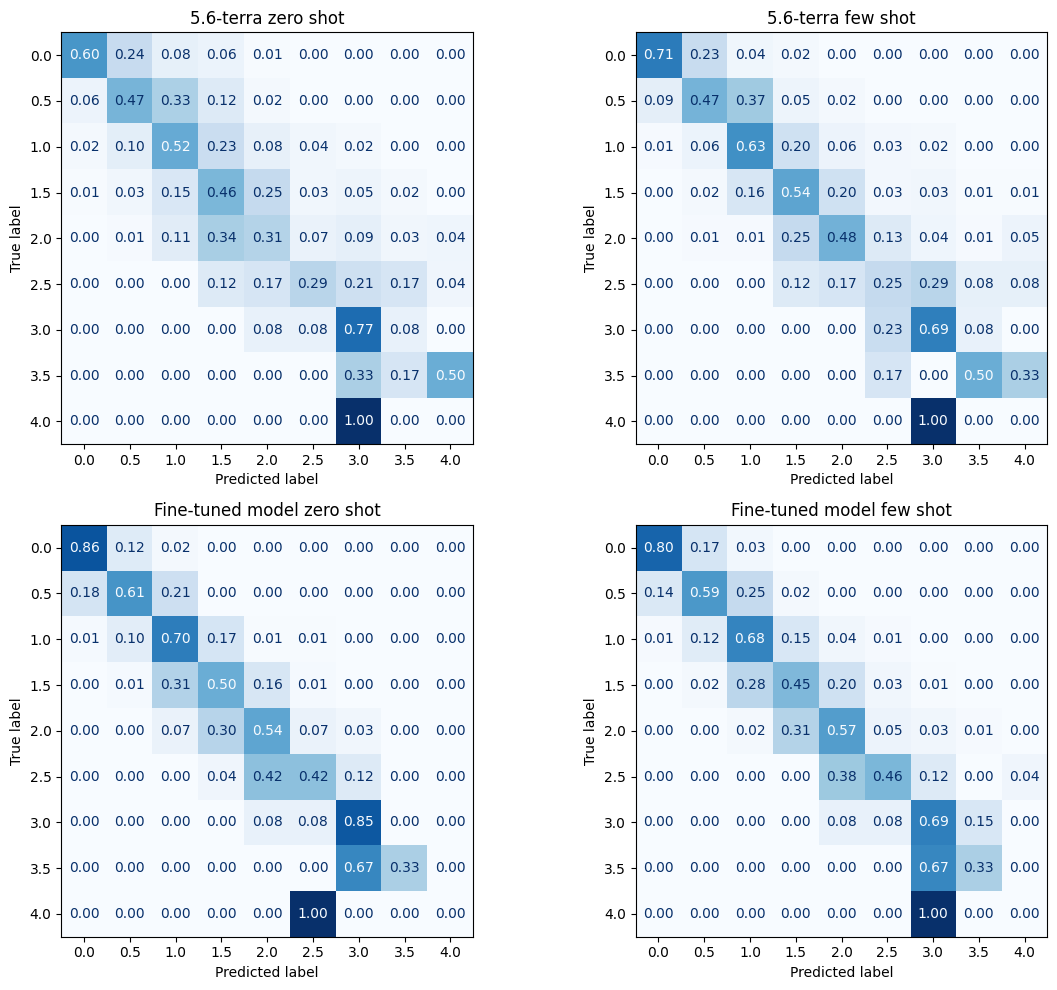

In [15]:
# Plot confusion matrices
results_list = [testing_zs_5_6_terra_med_output_df, testing_fs_5_6_terra_med_output_df, FTscores_zero_shot_output_df, FTscores_few_shot_output_df, ] 

plot_confusion_matrices(
    df=results_list, 
    target= "Human_Marker_Score",
    predicted= "Model_score_ROUNDED",
    name= ["5.6-terra zero shot", "5.6-terra few shot", "Fine-tuned model zero shot", "Fine-tuned model few shot", ],
    normalize= 'true',            #None, "true", "pred", "all"
    max_cols= 2,
    save_prefix= "Confusion Model Plots 5_6 + FT only",
)

In [9]:
FT_zero_shot_metrics = pd.read_csv(FTscores_zs_metrics_path)
FT_few_shot_metrics = pd.read_csv(FTscores_fs_metrics_path)
terra_5_6_med_zero_shot_metrics = pd.read_csv(zs_5_6_terra_med_metrics_path)
terra_5_6_med_few_shot_metrics = pd.read_csv(fs_5_6_terra_med_metrics_path)

Aggregate QWK scores by station for each condition into one dataframe

In [ ]:
QWK_comparison_across_conditions = FT_zero_shot_metrics[["question", "quad weighted kappa", "qwk_low", "qwk_high"]].rename(
    columns={"quad weighted kappa": "fine_tune_zs", "qwk_low":"FTzs_low", "qwk_high":"FTzs_high"})
QWK_comparison_across_conditions

In [ ]:
QWK_comparison_across_conditions = QWK_comparison_across_conditions.merge(
    FT_few_shot_metrics[["question", "quad weighted kappa", 'qwk_low', 'qwk_high']]
        .rename(columns={"quad weighted kappa": "fine_tune_fs", "qwk_low":"FTfs_low", "qwk_high":"FTfs_high"}),
    on="question",
    how="left"
)

QWK_comparison_across_conditions

In [ ]:
QWK_comparison_across_conditions = QWK_comparison_across_conditions.merge(
    terra_5_6_med_zero_shot_metrics[["question", "quad weighted kappa", 'qwk_low', 'qwk_high']]
        .rename(columns={"quad weighted kappa": "5.6-terra zero shot", "qwk_low":"5.6_zs_low", "qwk_high":"5.6_zs_high"}),
    on="question",
    how="left"
)

QWK_comparison_across_conditions

In [ ]:
QWK_comparison_across_conditions = QWK_comparison_across_conditions.merge(
    terra_5_6_med_few_shot_metrics[["question", "quad weighted kappa", 'qwk_low', 'qwk_high']]
        .rename(columns={"quad weighted kappa": "5.6-terra few shot", "qwk_low":"5.6_fs_low", "qwk_high":"5.6_fs_high"}),
    on="question",
    how="left"
)

QWK_comparison_across_conditions

In [16]:
removed_questions = ['3','12','13']

QWK_comparison_across_conditions["unseen_during_FT"] = (
    QWK_comparison_across_conditions["question"].isin(removed_questions)
)

In [ ]:
QWK_comparison_across_conditions["unseen_during_FT"]

In [ ]:

QWK_comparison_across_conditions


In [31]:
# Persist dataframe of QWK by station and condition
QWK_comparison_across_conditions.to_csv(cwd / "evaluation" / "QWK_comparison_across_conditions_v2.csv", index=False)

In [85]:
# to reload
QWK_comparison_across_conditions = pd.read_csv(cwd / "evaluation" / "QWK_comparison_across_conditions.csv")

Total scores by student

In [ ]:
# calculate total scores per student
human = (testing_zs_5_6_terra_med_output_df
        .groupby("Student_ID", as_index=False)["Human_Marker_Score"]
        .sum()
        .rename(columns={"Human_Marker_Score": "Human_Marker"}))

ft_zs = (FTscores_zero_shot_output_df
         .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
         .sum()
         .rename(columns={"Model_score_ROUNDED": "Fine tuned model Zero Shot"}))

ft_fs = (FTscores_few_shot_output_df
         .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
         .sum()
         .rename(columns={"Model_score_ROUNDED": "Fine tuned model Few Shot"}))

terra5_6_zs = (testing_zs_5_6_terra_med_output_df
        .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
        .sum()
        .rename(columns={"Model_score_ROUNDED": "5.6-terra Zero Shot"}))

terra5_6_fs = (testing_fs_5_6_terra_med_output_df
        .groupby("Student_ID", as_index=False)["Model_score_ROUNDED"]
        .sum()
        .rename(columns={"Model_score_ROUNDED": "5.6-terra Few Shot"}))

total_scores_df = human.merge(ft_zs, on="Student_ID", how="left") \
                        .merge(ft_fs, on="Student_ID", how="left") \
                        .merge(terra5_6_zs, on="Student_ID", how="left") \
                        .merge(terra5_6_fs, on="Student_ID", how="left")       

total_scores_df

In [ ]:
# # calculate differences between models and human scores for each student ** Note directional not MAD
total_scores_df["Fine_Tune_ZS_Delta"] = total_scores_df["Fine tuned model Zero Shot"] - total_scores_df["Human_Marker"]
total_scores_df["Fine_Tune_FS_Delta"] = total_scores_df["Fine tuned model Few Shot"] - total_scores_df["Human_Marker"]
total_scores_df["5.6_Zero_Shot_Delta"] = total_scores_df["5.6-terra Zero Shot"] - total_scores_df["Human_Marker"]
total_scores_df["5.6_Few_Shot_Delta"] = total_scores_df["5.6-terra Few Shot"] - total_scores_df["Human_Marker"]

total_scores_df

In [40]:
# persist total scores
total_scores_df.to_csv(cwd / "evaluation" / "total_scores_for_complete_students_by_model_v2.csv", index=False)

In [ ]:
# if need to reload
total_scores_df = pd.read_csv(cwd / "evaluation" / "total_scores_for_complete_students_by_model_v2.csv")
total_scores_df.columns


In [10]:
total_scores_df['Human_Marker'].describe()

count    58.000000
mean     14.206897
std       5.881904
min       1.500000
25%       9.750000
50%      14.250000
75%      18.875000
max      27.500000
Name: Human_Marker, dtype: float64

In [30]:
# Bootstrap function for total scores

def bootstrap_ci(series, n_boot=5000, ci=0.95, random_state=None):
        series = pd.to_numeric(series, errors="coerce").dropna()

        if len(series) == 0:
            return np.nan, np.nan

        results = []

        for i in range(n_boot):
            sample = series.sample(
                n=len(series),
                replace=True,
                random_state=(None if random_state is None else random_state + i)
            )
            results.append(sample.mean())

        alpha = (1 - ci) / 2
        return np.quantile(results, alpha), np.quantile(results, 1 - alpha)

Calculate means and 95% CIs for total scores under each condition

In [28]:
score_conditions = [
    'Human_Marker', 
    'Fine tuned model Zero Shot',
    'Fine tuned model Few Shot',
    '5.6-terra Zero Shot',
    '5.6-terra Few Shot'
]

results = []

for condition in score_conditions:
    mean = total_scores_df[condition].mean()
    conf_int = bootstrap_ci(total_scores_df[condition])
    conf_low = conf_int[0]
    conf_high = conf_int[1]
    output_dict = [condition, mean, conf_low, conf_high]
    results.append(output_dict)


columns = ["condition", "mean", "CI_low", "CI_high"]
total_score_mean_ci_df = pd.DataFrame(results, columns=columns)
total_score_mean_ci_df    

total_score_mean_ci_df

In [ ]:
#Persist total score means and 95% CIs
total_score_mean_ci_df.to_csv(cwd / "evaluation" / "total_score_mean_ci_v3.csv")

In [ ]:
# Calculate summary stats for total scores
summary_stats = total_scores_df[score_conditions].describe()

summary_stats

In [ ]:
# Calculate skew and kurtosis of total scores
summary_stats_skew_kurt = pd.DataFrame({
    "skew": total_scores_df[score_conditions].skew(),
    "kurtosis": total_scores_df[score_conditions].kurtosis()
})

summary_stats_skew_kurt


In [35]:
# Calculate Pearson's correlation between human scores and scores from each condition
pearson_results = {}

for col in score_conditions:
    if col == "Human_Marker":
        continue
    r, p = pearsonr(total_scores_df["Human_Marker"], total_scores_df[col])
    pearson_results[col] = {"r": r, "p_value": p}

pd.DataFrame(pearson_results).T

,r,p_value
Fine tuned model Zero Shot,0.966935,6.433717e-35
Fine tuned model Few Shot,0.965153,2.732896e-34
5.6-terra Zero Shot,0.954707,3.667396e-31
5.6-terra Few Shot,0.962370,2.263025e-33


Human vs LLM total score scatterplots by model and condition 

In [36]:
unwanted_columns = [
    'Human_Marker',
    'Fine_Tune_ZS_Delta', 
    'Fine_Tune_FS_Delta',
    '5.6_Zero_Shot_Delta', 
    '5.6_Few_Shot_Delta']

score_conditions_for_plot = [
    "5.6-terra Zero Shot",
    "5.6-terra Few Shot",
    "Fine tuned model Zero Shot",
    "Fine tuned model Few Shot"
]

score_condition_names = [
    "Unaltered new model (5.6-terra) Zero Shot",
    "Unaltered new model (5.6-terra) Few Shot",
    "Fine-tuned old model (4.1-mini) Zero Shot",
    "Fine-tuned old model (4.1-mini) Few Shot"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))


# flatten 2x2 array of axes into 1D list
axes = axes.flatten()

plot_idx = 0

for idx, col in enumerate(score_conditions_for_plot):

    if col in unwanted_columns:
        continue

    x = total_scores_df["Human_Marker"]
    y = total_scores_df[col]

    ax = axes[plot_idx]

    ax.scatter(x, y, alpha=0.7)

    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )
    col_name = score_condition_names[idx]
    ax.set_xlabel("Human_Marker")
    ax.set_ylabel(col)
    ax.set_title(f"Human vs {col_name}")

    plot_idx += 1

plt.tight_layout()

plt.show()



In [ ]:
# Persist fig
plt.savefig("total_score_plots_5_6_and_FT_only.png", dpi=300, bbox_inches="tight")

Calculate pass rates by model and condition

In [59]:
def determine_pass_rate_2(
    total_scores: pd.DataFrame,
    col_names: list,
    target_col: str,
    cut_score=20,
    bootstrap=True,
    n_boot=5000,
    ci=0.95,
    random_state=None,
):
    total_scores = total_scores.copy()

    def bootstrap_agreement_ci(agreement_series, n_boot=5000, ci=0.95, random_state=None):
        agreement_series = agreement_series.dropna()

        categories = ["True_Pass", "False_Fail", "False_Pass", "True_Fail"]

        if len(agreement_series) == 0:
            return {cat: (np.nan, np.nan) for cat in categories}

        boot_results = {cat: [] for cat in categories}

        for i in range(n_boot):
            sample = agreement_series.sample(
                n=len(agreement_series),
                replace=True,
                random_state=(None if random_state is None else random_state + i)
            )

            proportions = sample.value_counts(normalize=True)

            for cat in categories:
                boot_results[cat].append(proportions.get(cat, 0))

        alpha = (1 - ci) / 2

        return {
            cat: (
                np.quantile(boot_results[cat], alpha),
                np.quantile(boot_results[cat], 1 - alpha)
            )
            for cat in categories
        }

    summary_stats = []

    # First create all pass/fail columns
    for col in col_names:
        pass_col = f"{col}_pass"

        total_scores[pass_col] = np.where(
            pd.to_numeric(total_scores[col], errors="coerce") >= cut_score,
            1,
            0
        )

    target_pass_col = f"{target_col}_pass"

    # Then calculate summary stats and agreement columns
    for col in col_names:
        pass_col = f"{col}_pass"

        pass_rate = total_scores[pass_col].mean()

        col_result = {
            "condition": col,
            "cut_score": cut_score,
            "pass_rate": pass_rate,
            "n_pass": total_scores[pass_col].sum(),
            "n_total": total_scores[pass_col].notna().sum(),
        }

        if bootstrap:
            pass_rate_low, pass_rate_high = bootstrap_ci(
                total_scores[pass_col],
                n_boot=n_boot,
                ci=ci,
                random_state=random_state
            )

            col_result["pass_rate_low"] = pass_rate_low
            col_result["pass_rate_high"] = pass_rate_high

        if col != target_col:
            agreement_col = f"{col}_agreement"

            conditions = [
                (total_scores[target_pass_col] == 1) & (total_scores[pass_col] == 1),
                (total_scores[target_pass_col] == 1) & (total_scores[pass_col] == 0),
                (total_scores[target_pass_col] == 0) & (total_scores[pass_col] == 1),
                (total_scores[target_pass_col] == 0) & (total_scores[pass_col] == 0),
            ]

            choices = [
                "True_Pass",
                "False_Fail",
                "False_Pass",
                "True_Fail",
            ]

            total_scores[agreement_col] = np.select(
                conditions,
                choices,
                default="Missing"
            )

            agreement_counts = total_scores[agreement_col].value_counts(dropna=False)
            n_total = col_result["n_total"]

            col_result["true_pass"] = agreement_counts.get("True_Pass", 0)
            col_result["false_fail"] = agreement_counts.get("False_Fail", 0)
            col_result["false_pass"] = agreement_counts.get("False_Pass", 0)
            col_result["true_fail"] = agreement_counts.get("True_Fail", 0)

            col_result["true_pass_rate"] = col_result["true_pass"] / n_total
            col_result["false_fail_rate"] = col_result["false_fail"] / n_total
            col_result["false_pass_rate"] = col_result["false_pass"] / n_total
            col_result["true_fail_rate"] = col_result["true_fail"] / n_total

            if bootstrap:
                agreement_cis = bootstrap_agreement_ci(
                    total_scores[agreement_col],
                    n_boot=n_boot,
                    ci=ci,
                    random_state=random_state
                )

                col_result["true_pass_rate_low"] = agreement_cis["True_Pass"][0]
                col_result["true_pass_rate_high"] = agreement_cis["True_Pass"][1]

                col_result["false_fail_rate_low"] = agreement_cis["False_Fail"][0]
                col_result["false_fail_rate_high"] = agreement_cis["False_Fail"][1]

                col_result["false_pass_rate_low"] = agreement_cis["False_Pass"][0]
                col_result["false_pass_rate_high"] = agreement_cis["False_Pass"][1]

                col_result["true_fail_rate_low"] = agreement_cis["True_Fail"][0]
                col_result["true_fail_rate_high"] = agreement_cis["True_Fail"][1]

        summary_stats.append(col_result)

    summary_results_df = pd.DataFrame(summary_stats)

    return total_scores, summary_results_df

In [64]:
# call function to calculate pass rates by condition and 95% CIs
total_scores, pass_rates_agreement_df = determine_pass_rate_2(
    total_scores= total_scores_df,
    col_names = score_conditions,
    target_col= 'Human_Marker',
    cut_score=20,
    bootstrap=True,
    n_boot=5000,
    ci=0.95,
    random_state=None,
    )

In [ ]:
# view pass rates summary data
pass_rates_agreement_df

In [65]:
# Persist pass rates summary data
pass_rates_agreement_df.to_csv(cwd / "evaluation" / "pass_rates_agreement.csv_v2", index=False)

In [ ]:
# Reload if required
pass_rates_agreement_df = pd.read_csv(cwd / "evaluation" / "pass_rates_agreement.csv_v2")
pass_rates_agreement_df

Plot pass rates by condition

In [ ]:
selected_conditions = ["Human_Marker", "5.6-terra Zero Shot", "5.6-terra Few Shot", "Fine tuned model Zero Shot", "Fine tuned model Few Shot"]

plot_df = (
    pass_rates_agreement_df
    .set_index("condition")
    .loc[selected_conditions]
    .reset_index()
)

score_condition_names_2 = [
    "Human",
    'Unaltered new model Zero Shot',
    'Unaltered new model Few Shot',
    'Fine-tuned old model Zero Shot',
    'Fine-tuned old model Few Shot'
]

plot_df["condition_name"] = score_condition_names_2


# Plot pass rates by condition
x = np.arange(len(plot_df))

y = plot_df["pass_rate"]
y_lower = plot_df["pass_rate"] - plot_df["pass_rate_low"]
y_upper = plot_df["pass_rate_high"] - plot_df["pass_rate"]

plt.figure(figsize=(6, 8))

colours = ["green", "steelblue","steelblue","red","red"]
plt.bar(
    x,
    y,
    yerr=[y_lower, y_upper],
    capsize=5,
    color=colours
)

plt.xticks(
    x,
    plot_df["condition_name"],
    rotation=45,
    ha="right"
)

plt.ylabel("Pass rate")
plt.xlabel("Condition")
plt.title("Pass rate by condition with 95% confidence intervals")
plt.ylim(0, 0.7)

plt.tight_layout()
pass_rate_plot_path = cwd / "evaluation" / "pass_rate_plot.png"
plt.savefig(pass_rate_plot_path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# view total scores df
total_scores

In [67]:
# persist total score and pass/fail by condition
total_scores.to_csv(cwd / "evaluation" / "total_scores_pass_fail_by_condition_v2.csv")